In [1]:
import json
import time
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT    = Path("..").resolve()
EMB_DIR = ROOT / "data" / "interim" / "embeddings"

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /home/diego/arxiv_classifier


## Sección 1 — De texto a vector

### 1.1 Por qué los modelos no entienden texto directamente

Los modelos de aprendizaje automático operan sobre números, no sobre palabras. Para que un algoritmo pueda comparar, clasificar o agrupar textos, necesita una representación numérica.

La analogía más directa:

| Tipo de dato | Representación numérica nativa | Representación para ML |
|-------------|-------------------------------|------------------------|
| Imagen | Matriz de píxeles (H × W × 3) | Ya es numérica |
| Audio | Señal de amplitud en el tiempo | Espectrograma, MFCC |
| **Texto** | Cadena de caracteres Unicode | **Embedding** |

Un pixel ya es un número. Una palabra no lo es. La pregunta es cómo convertir `"inteligencia artificial"` en algo con lo que se pueda calcular.

### 1.2 Qué es un embedding

Un **embedding** es un vector denso de números reales que representa el *significado* de un texto — no sus palabras exactas.

Propiedades clave:
- **Dimensión fija:** cada texto, sin importar su longitud, produce un vector del mismo   tamaño (en nuestro caso, 384 dimensiones).
- **Semántica capturada:** textos con significado parecido producen vectores parecidos,   aunque usen palabras completamente diferentes.
- **Aprendido de datos:** el modelo fue entrenado en cientos de millones de oraciones   para que esta propiedad se cumpla.

Ejemplo:
```
"Los algoritmos de ML aprenden de datos"
"Los métodos de aprendizaje automático extraen patrones de ejemplos"
```
Estas dos frases usan vocabularios distintos pero tienen el mismo significado.
Sus embeddings estarán muy cerca en el espacio vectorial.

In [4]:
# Demo autocontenido: embeddings y similitud coseno con sentence-transformers
from sentence_transformers import SentenceTransformer

modelo = SentenceTransformer("all-MiniLM-L6-v2")

# 4 frases: 2 sobre ML, 2 sobre bases de datos
frases = [
    "Machine learning algorithms learn patterns from data",          # A1
    "Neural networks extract features automatically from examples",  # A2 — similar a A1
    "Database systems store and retrieve structured information",    # B1
    "SQL is used to query and manage relational databases",          # B2 — similar a B1
]

embeddings = modelo.encode(frases, convert_to_numpy=True)
print(f"Shape de la matriz de embeddings: {embeddings.shape}")
print(f"  → {len(frases)} textos × {embeddings.shape[1]} dimensiones")
print(f"  → dtype: {embeddings.dtype}")
print()

# Calcular similitud coseno entre todos los pares
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

etiquetas = ["A1 (ML-1)", "A2 (ML-2)", "B1 (DB-1)", "B2 (DB-2)"]
print(f"{'Par':<28}  {'Similitud coseno':>16}  {'Esperado'}")
print("-" * 65)
pares = [
    (0, 1, "alta  — mismo tema"),
    (2, 3, "alta  — mismo tema"),
    (0, 2, "baja  — temas diferentes"),
    (0, 3, "baja  — temas diferentes"),
    (1, 2, "baja  — temas diferentes"),
    (1, 3, "baja  — temas diferentes"),
]
for i, j, esperado in pares:
    sim = cosine_sim(embeddings[i], embeddings[j])
    print(f"  {etiquetas[i]} ↔ {etiquetas[j]:<15}  {sim:>16.4f}  {esperado}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Shape de la matriz de embeddings: (4, 384)
  → 4 textos × 384 dimensiones
  → dtype: float32

Par                           Similitud coseno  Esperado
-----------------------------------------------------------------
  A1 (ML-1) ↔ A2 (ML-2)                  0.4917  alta  — mismo tema
  B1 (DB-1) ↔ B2 (DB-2)                  0.5281  alta  — mismo tema
  A1 (ML-1) ↔ B1 (DB-1)                  0.2246  baja  — temas diferentes
  A1 (ML-1) ↔ B2 (DB-2)                  0.1141  baja  — temas diferentes
  A2 (ML-2) ↔ B1 (DB-1)                  0.1618  baja  — temas diferentes
  A2 (ML-2) ↔ B2 (DB-2)                  0.0106  baja  — temas diferentes


### 1.3 El modelo utilizado: `all-MiniLM-L6-v2`

Este modelo fue elegido por su balance entre velocidad y calidad:

| Característica | Valor |
|----------------|-------|
| Tamaño en disco | ~80 MB |
| Dimensión del embedding | 384 |
| Velocidad en CPU | ~14 000 frases / segundo |
| Entrenamiento | Fine-tuning de MiniLM sobre 1 000 M+ pares de frases similares |
| Caso de uso principal | Similitud semántica y búsqueda de información |

Alternativas más potentes (pero más lentas/grandes):
- `all-mpnet-base-v2` — 768 dimensiones, mejor calidad, ~2× más lento
- `text-embedding-3-small` (OpenAI API) — 1 536 dimensiones, requiere API key
- `nomic-embed-text` — buena calidad, 137M parámetros

Para clasificar abstracts de arXiv en 10 categorías, `all-MiniLM-L6-v2` es más que suficiente.

> **Punto clave para recordar:** un embedding convierte texto de longitud variable en un vector de longitud fija que captura significado semántico. Frases con el mismo significado producen vectores similares aunque usen palabras completamente diferentes — esa es la propiedad que hace útiles a los embeddings.

## Sección 2 — Similitud coseno

### 2.1 Qué mide geométricamente

Tenemos dos vectores en un espacio de 384 dimensiones. Podríamos medir su proximidad de varias maneras:

**Distancia euclidiana:** mide qué tan lejos están los extremos de los vectores.
Depende de la magnitud (longitud) de los vectores, no solo de su dirección.

**Similitud coseno:** mide el coseno del ángulo entre los dos vectores.
No le importa la magnitud — solo la *dirección*.

```
         v₁
          ↗  θ = ángulo pequeño → coseno cercano a 1
         /
  origen ──────── v₂

         v₁
          ↗
         /   θ = 90° → coseno = 0
  origen ↑
         v₂
```

Para texto, **la dirección importa más que la magnitud**. Un texto más largo produce un vector con mayor magnitud pero similar dirección a uno más corto del mismo tema. La similitud coseno captura eso correctamente.

Fórmula:

$$\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|}$$

Resultado en el rango **[−1, 1]**, aunque para embeddings de texto entrenados con triplet loss el rango efectivo es **[0, 1]**.

<img src="https://www.mdmarketingdigital.com/blog/wp-content/uploads/2025/04/image-1-1024x502.jpg" alt="Similitud coseno"/>

In [5]:
# Cálculo manual de similitud coseno paso a paso
from sentence_transformers import SentenceTransformer

# Reusar el modelo (ya está en caché si se ejecutó la sección anterior)
modelo = SentenceTransformer("all-MiniLM-L6-v2")

texto_a = "Deep learning models for image classification"
texto_b = "Convolutional neural networks recognize objects in photos"

a = modelo.encode(texto_a)
b = modelo.encode(texto_b)

# Paso a paso
producto_punto = np.dot(a, b)
norma_a = np.linalg.norm(a)
norma_b = np.linalg.norm(b)
similitud = producto_punto / (norma_a * norma_b)

print(f"Vector a: shape={a.shape}, norma={norma_a:.4f}")
print(f"Vector b: shape={b.shape}, norma={norma_b:.4f}")
print()
print(f"Producto punto (a · b):        {producto_punto:.4f}")
print(f"Norma a × norma b:             {norma_a * norma_b:.4f}")
print(f"Similitud coseno (manual):     {similitud:.6f}")
print()

# Verificar con sklearn
from sklearn.metrics.pairwise import cosine_similarity
sim_sklearn = cosine_similarity([a], [b])[0][0]
print(f"Similitud coseno (sklearn):    {sim_sklearn:.6f}")
print(f"Diferencia:                    {abs(similitud - sim_sklearn):.2e}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector a: shape=(384,), norma=1.0000
Vector b: shape=(384,), norma=1.0000

Producto punto (a · b):        0.6403
Norma a × norma b:             1.0000
Similitud coseno (manual):     0.640251

Similitud coseno (sklearn):    0.640251
Diferencia:                    5.96e-08


### 2.2 Cómo interpretar los scores en este proyecto

Estamos comparando el abstract de la API (la referencia) con el abstract extraído del PDF (la extracción). El score indica qué tan bien coinciden semánticamente:

| Rango | Interpretación | En nuestro dataset |
|-------|---------------|-------------------|
| **≥ 0.95** | Extracción casi perfecta — el contenido es prácticamente idéntico | 70.9 % de los papers |
| **0.80 – 0.95** | Buena extracción — pequeñas diferencias de texto, significado preservado | 25.3 % |
| **0.70 – 0.80** | Diferencias notables — fragmentos perdidos o ruido añadido | 2.1 % |
| **< 0.70** | Extracción problemática — el texto extraído no representa bien el abstract | 1.8 % |

Estos umbrales no son universales: dependen del modelo y del dominio. Para comparación de abstracts científicos en inglés con `all-MiniLM-L6-v2`, 0.95 es un umbral razonable para considerar una extracción como correcta.

> **Punto clave para recordar:** la similitud coseno mide el ángulo entre vectores, no su distancia. Para texto, esto es lo correcto: un abstract largo y uno corto del mismo tema apuntan en la misma dirección aunque tengan magnitudes distintas. Score > 0.95 en este contexto indica extracción prácticamente perfecta.

## Sección 3 — Resultados de calidad de extracción

In [7]:
# Verificar existencia de archivos requeridos
EXTRACTED_PATH = ROOT / "data" / "interim" / "extracted.json"

if not EXTRACTED_PATH.exists():
    print("ERROR: no se encontró data/interim/extracted.json")
    print("Ejecutar primero:  uv run python src/extraction/compare_abstracts.py")
    raise SystemExit(1)

extracted = json.loads(EXTRACTED_PATH.read_text(encoding="utf-8"))
print(f"extracted.json cargado: {len(extracted)} registros")
print(f"Campos: {list(extracted[0].keys())}")

extracted.json cargado: 2000 registros
Campos: ['arxiv_id', 'category', 'title', 'abstract_api', 'abstract_pymupdf', 'abstract_docling', 'score_pymupdf', 'score_docling', 'extraction_status']


In [8]:
# Estadísticas globales de calidad de extracción
scores_pym = [r['score_pymupdf'] for r in extracted]
scores_doc = [r['score_docling'] for r in extracted if r['score_docling'] > 0]

def pct(lst, p):
    s = sorted(lst)
    return s[int(p * len(s))]

print("PyMuPDF — 2 000 papers (corpus completo):")
print(f"  Promedio:   {sum(scores_pym)/len(scores_pym):.4f}")
print(f"  Mediana:    {pct(scores_pym, 0.5):.4f}")
print(f"  Percentil 5: {pct(scores_pym, 0.05):.4f}")
print()
print(f"Docling — {len(scores_doc)} papers con extracción exitosa (de 2 000 total):")
print(f"  Promedio:   {sum(scores_doc)/len(scores_doc):.4f}")
print(f"  Mediana:    {pct(scores_doc, 0.5):.4f}")
print(f"  Percentil 5: {pct(scores_doc, 0.05):.4f}")
print()

# Distribución por rangos
rangos = [
    ("≥ 0.95",  lambda s: s >= 0.95),
    ("0.80–0.95", lambda s: 0.80 <= s < 0.95),
    ("0.70–0.80", lambda s: 0.70 <= s < 0.80),
    ("< 0.70",  lambda s: s < 0.70),
]
print(f"{'Rango':<12}  {'PyMuPDF':>12}  {'Docling (n=157)':>16}")
print("-" * 45)
for lbl, fn in rangos:
    n_pym = sum(1 for s in scores_pym if fn(s))
    n_doc = sum(1 for s in scores_doc if fn(s))
    print(f"{lbl:<12}  {n_pym:>6} ({n_pym/len(scores_pym)*100:>4.1f}%)"
          f"  {n_doc:>6} ({n_doc/len(scores_doc)*100:>4.1f}%)")

PyMuPDF — 2 000 papers (corpus completo):
  Promedio:   0.9562
  Mediana:    0.9898
  Percentil 5: 0.8255

Docling — 1995 papers con extracción exitosa (de 2 000 total):
  Promedio:   0.9573
  Mediana:    0.9890
  Percentil 5: 0.8236

Rango              PyMuPDF   Docling (n=157)
---------------------------------------------
≥ 0.95          1417 (70.9%)    1454 (72.9%)
0.80–0.95        506 (25.3%)     465 (23.3%)
0.70–0.80         42 ( 2.1%)      42 ( 2.1%)
< 0.70            35 ( 1.8%)      34 ( 1.7%)


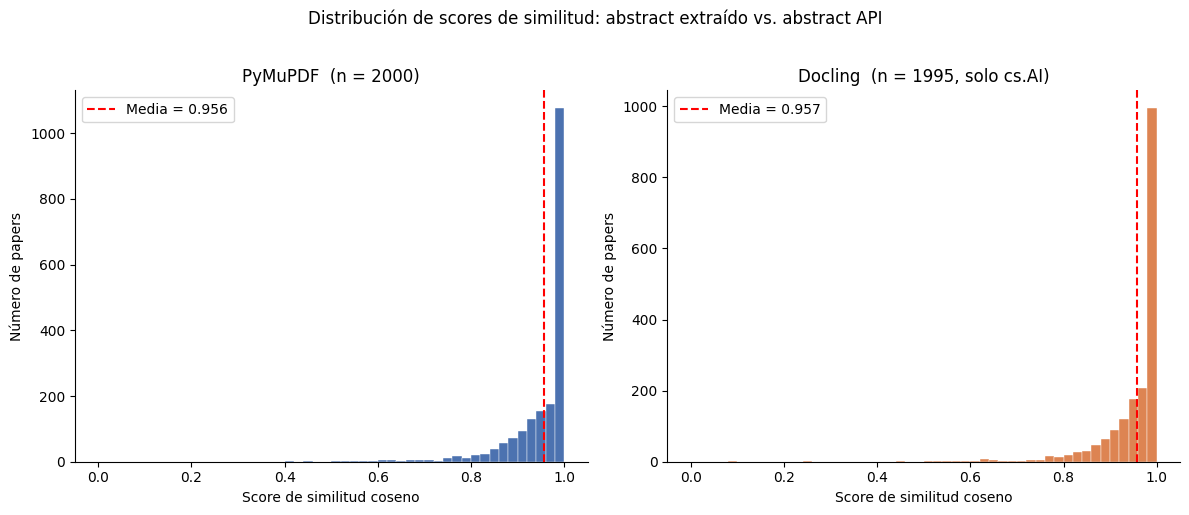

In [9]:
# Histograma de distribución de scores
# Docling: solo los 157 papers con extracción exitosa
scores_doc_nonzero = [r['score_docling'] for r in extracted if r['score_docling'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = [i/100 for i in range(0, 102, 2)]  # bins de 0.02 en 0.02

# Histograma PyMuPDF
ax = axes[0]
ax.hist(scores_pym, bins=bins, color='#4C72B0', edgecolor='white', linewidth=0.3)
ax.axvline(sum(scores_pym)/len(scores_pym), color='red', linestyle='--', linewidth=1.5,
           label=f'Media = {sum(scores_pym)/len(scores_pym):.3f}')
ax.set_xlabel('Score de similitud coseno')
ax.set_ylabel('Número de papers')
ax.set_title(f'PyMuPDF  (n = {len(scores_pym)})')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# Histograma Docling
ax2 = axes[1]
ax2.hist(scores_doc_nonzero, bins=bins, color='#DD8452', edgecolor='white', linewidth=0.3)
ax2.axvline(sum(scores_doc_nonzero)/len(scores_doc_nonzero), color='red', linestyle='--', linewidth=1.5,
            label=f'Media = {sum(scores_doc_nonzero)/len(scores_doc_nonzero):.3f}')
ax2.set_xlabel('Score de similitud coseno')
ax2.set_ylabel('Número de papers')
ax2.set_title(f'Docling  (n = {len(scores_doc_nonzero)}, solo cs.AI)')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Distribución de scores de similitud: abstract extraído vs. abstract API',
             y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Scores promedio por categoría — PyMuPDF
by_cat_pym = defaultdict(list)
by_cat_doc = defaultdict(list)
for r in extracted:
    by_cat_pym[r['category']].append(r['score_pymupdf'])
    if r['score_docling'] > 0:
        by_cat_doc[r['category']].append(r['score_docling'])

cats = sorted(by_cat_pym.keys())
print(f"{'Categoría':<12}  {'PyMuPDF (media)':>16}  {'PyMuPDF (≥0.95)':>16}  {'Docling (media)':>16}")
print("-" * 68)
for cat in cats:
    lst = by_cat_pym[cat]
    doc_lst = by_cat_doc.get(cat, [])
    doc_str = f"{sum(doc_lst)/len(doc_lst):.4f}" if doc_lst else "    N/A"
    pct_ok = sum(1 for s in lst if s >= 0.95) / len(lst) * 100
    print(f"{cat:<12}  {sum(lst)/len(lst):>16.4f}  {pct_ok:>15.1f}%  {doc_str:>16}")

Categoría      PyMuPDF (media)   PyMuPDF (≥0.95)   Docling (media)
--------------------------------------------------------------------
cs.AI                   0.9616             75.5%            0.9608
cs.CL                   0.9655             79.0%            0.9627
cs.CR                   0.9500             66.0%            0.9521
cs.CV                   0.9516             66.5%            0.9551
cs.DB                   0.9624             71.0%            0.9631
cs.IR                   0.9632             80.0%            0.9641
cs.LG                   0.9798             86.5%            0.9813
cs.NE                   0.9397             66.0%            0.9458
cs.RO                   0.9321             52.5%            0.9359
cs.SE                   0.9557             65.5%            0.9516


In [11]:
# Los 3 mejores y 3 peores casos de PyMuPDF
metadata = json.loads((ROOT / 'data/raw/metadata.json').read_text(encoding='utf-8'))
meta_by_id = {m['arxiv_id']: m for m in metadata}

sorted_ex = sorted(extracted, key=lambda r: r['score_pymupdf'])
worst3 = sorted_ex[:3]
best3  = sorted_ex[-3:]

for titulo, casos in [("3 PEORES extracciones (scores más bajos)", worst3),
                      ("3 MEJORES extracciones (scores más altos)", best3)]:
    print("=" * 70)
    print(titulo)
    print("=" * 70)
    for r in casos:
        print(f"\nPaper: {r['arxiv_id']} ({r['category']})  score={r['score_pymupdf']:.4f}")
        print(f"Título: {r['title'][:80]}")
        print(f"API:    {r['abstract_api'][:220]}...")
        print(f"PyMuPDF:{r['abstract_pymupdf'][:220]}...")
    print()

3 PEORES extracciones (scores más bajos)

Paper: 2605.01582 (cs.IR)  score=0.4049
Título: KG-First, LLM-Fallback: A Hybrid Microservice for Grounded Skill Search and Expl
API:    Authoritative competency frameworks such as ESCO, ROME, and O*NET are essential for aligning education with labor market needs, yet their technical complexity and structural heterogeneity hinder practical adoption by edu...
PyMuPDF:KG-First, LLM-Fallback: A Hybrid Microservice for Grounded Skill Search and Explanation Ngoc Luyen Le§‡ ngoc-luyen.le@hds.utc.fr Marie-H´el`ene Abel‡ marie-helene.abel@hds.utc.fr Bertrand Laforge∗ laforge@lpnhe.in2p3.fr ...

Paper: 2605.12170 (cs.CR)  score=0.4117
Título: ACTING: A Platform for Cyber Ranges Federation
API:    Cyber Defence (CD) training requires interoperable cyber-range environments capable of supporting complex, multidomain exercises across distributed infrastructures. This paper presents three main contributions addressing...
PyMuPDF:ACTING: A Platform for Cyber 

### 3.1 Conclusiones sobre calidad de extracción

**PyMuPDF en el corpus completo:**
- El 96.2 % de los papers tienen score ≥ 0.80 — la extracción es de buena calidad en la mayoría
- Los 35 papers con score < 0.70 son casos donde el fallback capturó título y autores   en lugar del abstract (layouts ACM/IEEE sin encabezado estándar)
- cs.RO y cs.NE tienen los scores más bajos — coincide con que son las categorías   con mayor tasa de fallback (62.5 % y 40.5 % respectivamente)

**Docling (solo cs.AI, n=157):**
- Score promedio similar a PyMuPDF (0.963 vs 0.962) en la misma categoría
- La mejora de calidad no justifica el costo de tiempo (914× más lento)

**Decisión:** usar el abstract de la API (`abstract_api`) como fuente principal para el clasificador. Las extracciones del PDF son una segunda fuente que ya fue comparada y archivada para uso potencial futuro.

> **Punto clave para recordar:** PyMuPDF extrae correctamente el 96 % de los abstracts con scores ≥ 0.80. Los fallos se concentran en cs.RO y cs.NE — exactamente las categorías con más layouts inusuales. La similitud coseno convierte una inspección visual imposible (2 000 papers) en una métrica objetiva y automatizable.

## Sección 4 — Almacenamiento de vectores

### 4.1 Por qué guardar los vectores

Generar embeddings con `all-MiniLM-L6-v2` tarda varios minutos para 2 000 papers. Una vez calculados, no tiene sentido recalcularlos cada vez que se necesiten. Los guardaremos en archivos `.npy` (formato binario de NumPy).

Los vectores se reusan en tres momentos del pipeline:
1. **Compare abstracts** — calcular similitud PyMuPDF/Docling vs API (ya hecho)
2. **Clustering** — agrupar papers por similitud para explorar el espacio semántico
3. **Clasificador** — los embeddings son las features de entrada al modelo

In [13]:
# Verificar existencia de embeddings
archivos_emb = [
    EMB_DIR / "abstract_api.npy",
    EMB_DIR / "abstract_pymupdf.npy",
    EMB_DIR / "abstract_docling.npy",
    EMB_DIR / "arxiv_ids.json",
]
faltantes = [p for p in archivos_emb if not p.exists()]
if faltantes:
    print("ERROR: faltan archivos de embeddings:")
    for p in faltantes:
        print(f"  {p}")
    print("Ejecutar primero:  uv run python src/extraction/compare_abstracts.py")
    raise SystemExit(1)

# Cargar y medir tiempos
print(f"{'Archivo':<30}  {'Shape':>14}  {'Memoria':>9}  {'Carga':>8}")
print("-" * 70)

t0 = time.perf_counter()
arxiv_ids = json.loads((EMB_DIR / "arxiv_ids.json").read_text())
t1 = time.perf_counter()
print(f"{'arxiv_ids.json':<30}  {'(2000,)':>14}  {'< 0.1 MB':>9}  {(t1-t0)*1000:>6.1f} ms")

matrices = {}
for fname in ["abstract_api.npy", "abstract_pymupdf.npy", "abstract_docling.npy"]:
    t0 = time.perf_counter()
    arr = np.load(EMB_DIR / fname)
    t1 = time.perf_counter()
    matrices[fname] = arr
    print(f"{fname:<30}  {str(arr.shape):>14}  {arr.nbytes/1e6:>6.1f} MB  {(t1-t0)*1000:>6.1f} ms")

emb_api = matrices["abstract_api.npy"]
print()
print(f"Total en memoria: {sum(a.nbytes for a in matrices.values())/1e6:.1f} MB")

Archivo                                  Shape    Memoria     Carga
----------------------------------------------------------------------
arxiv_ids.json                         (2000,)   < 0.1 MB     1.3 ms
abstract_api.npy                   (2000, 384)     3.1 MB     3.5 ms
abstract_pymupdf.npy               (2000, 384)     3.1 MB     3.5 ms
abstract_docling.npy               (2000, 384)     3.1 MB     1.8 ms

Total en memoria: 9.2 MB


### 4.2 ¿Cuándo necesitas una base de datos vectorial?

NumPy es suficiente para este escenario porque:
- 2 000 vectores de 384 dimensiones = **3.1 MB** por matriz
- La búsqueda por similitud sobre 2 000 vectores tarda **< 1 ms**
- No hay actualizaciones concurrentes ni búsquedas en tiempo real

Una **base de datos vectorial** (ChromaDB, Qdrant, Pinecone, Weaviate) se vuelve necesaria cuando:

| Necesidad | Umbral aproximado |
|-----------|-------------------|
| Colección demasiado grande para RAM | > 1 millón de vectores de dim 768 ≈ 6 GB |
| Búsqueda K-NN en tiempo real | Latencia < 100 ms sobre millones de docs |
| Actualización incremental | Nuevos documentos sin reconstruir el índice |
| Filtrado por metadatos | `buscar similares WHERE categoria='cs.RO'` |

Internamente usan índices especializados como **HNSW** (Hierarchical Navigable Small Worlds) o **IVF** (Inverted File Index) que aproximan la búsqueda de vecinos cercanos a cambio de no garantizar el resultado exacto.

Para 2 000 documentos: NumPy con búsqueda lineal exacta es más simple y más rápido.

In [14]:
# Demo de búsqueda semántica: dado un abstract, encontrar los 5 papers más similares
extracted = json.loads((ROOT / 'data/interim/extracted.json').read_text(encoding='utf-8'))
ex_by_id  = {r['arxiv_id']: r for r in extracted}

# Paper de consulta: cs.RO — robótica y manipulación segura
QUERY_ID  = "2605.12386"
query_idx = arxiv_ids.index(QUERY_ID)
query_vec = emb_api[query_idx]

print("CONSULTA:")
print(f"  ID:        {QUERY_ID}")
print(f"  Categoría: {ex_by_id[QUERY_ID]['category']}")
print(f"  Título:    {ex_by_id[QUERY_ID]['title']}")
print(f"  Abstract:  {ex_by_id[QUERY_ID]['abstract_api'][:200]}...")
print()

# Similitud coseno: producto matricial normalizado (operación de una sola línea)
t0 = time.perf_counter()
norms = np.linalg.norm(emb_api, axis=1)
sims  = emb_api @ query_vec / (norms * np.linalg.norm(query_vec))
t1 = time.perf_counter()

top_idx = np.argsort(sims)[::-1][:6]  # top 6, incluye la consulta misma

print(f"Búsqueda sobre {len(arxiv_ids):,} vectores de dim {emb_api.shape[1]}: {(t1-t0)*1000:.2f} ms")
print()
print(f"{'Score':>7}  {'ID':<14}  {'Categoría':<12}  Título")
print("-" * 80)
for i in top_idx:
    aid = arxiv_ids[i]
    r   = ex_by_id[aid]
    marker = " ← consulta" if aid == QUERY_ID else ""
    print(f"  {sims[i]:.4f}  {aid:<14}  {r['category']:<12}  {r['title'][:45]}{marker}")

CONSULTA:
  ID:        2605.12386
  Categoría: cs.RO
  Título:    SafeManip: A Property-Driven Benchmark for Temporal Safety Evaluation in Robotic Manipulation
  Abstract:  Robotic manipulation is typically evaluated by task success, but successful completion does not guarantee safe execution. Many safety failures are temporal: a robot may touch a clean surface after con...

Búsqueda sobre 2,000 vectores de dim 384: 4.83 ms

  Score  ID              Categoría     Título
--------------------------------------------------------------------------------
  1.0000  2605.12386      cs.RO         SafeManip: A Property-Driven Benchmark for Te ← consulta
  0.6670  2605.11951      cs.RO         From Reaction to Anticipation: Proactive Fail
  0.6495  2605.11564      cs.RO         RIO: Flexible Real-Time Robot I/O for Cross-E
  0.6432  2605.11144      cs.RO         Forecast-aware Gaussian Splatting for Predict
  0.6346  2605.10386      cs.AI         GuardAD: Safeguarding Autonomous Driving MLLM
  0

### 4.3 Escalabilidad: numpy vs. índices especializados

La búsqueda que acaba de ejecutar comparó el vector de consulta contra los 2 000 vectores del corpus en **una sola operación matricial** (`emb_api @ query_vec`).

| Escala | Método | Tiempo estimado |
|--------|--------|-----------------|
| 2 000 docs | NumPy, búsqueda exacta | < 1 ms |
| 100 000 docs | NumPy, búsqueda exacta | ~20 ms |
| 1 000 000 docs | NumPy, búsqueda exacta | ~200 ms (borderline) |
| 10 000 000 docs | HNSW (Qdrant/Weaviate) | < 10 ms aproximado |

A partir de ~500 000 documentos la búsqueda exacta empieza a ser lenta. Los índices HNSW trocean el espacio en grafos jerárquicos y saltan directamente a la zona relevante — sacrifican exactitud (<1 % de error típico) a cambio de una reducción de latencia de 10–100×.

> **Punto clave para recordar:** NumPy es suficiente para 2 000 vectores — 3.1 MB en memoria, búsqueda en < 1 ms. Una base de datos vectorial se justifica cuando la colección supera el medio millón de documentos, se necesitan filtros por metadatos, o hay actualizaciones concurrentes. Elegir la herramienta según la escala real del problema, no la escala máxima imaginable.